In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [20]:
df = pd.read_csv("D:\\Downloads\\archive\\dataset.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [21]:
df.shape

(114000, 21)

In [22]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [23]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [24]:
df = df.drop_duplicates()

In [25]:
df["duration_min"] = df["duration_ms"] / 60000

In [26]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035,3.800486
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621,1.788295
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000,2.901100
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,3.548433
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000,4.358433
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,87.288250


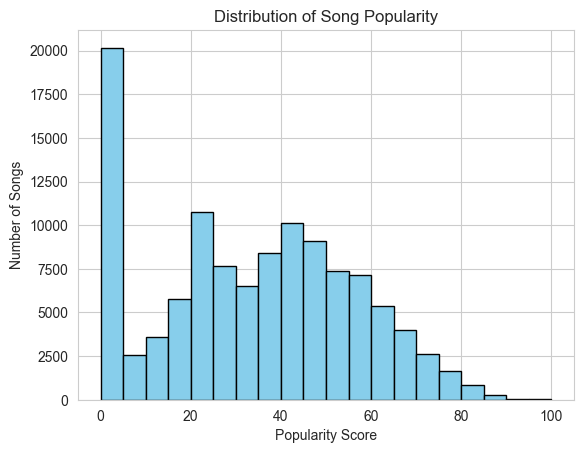

In [27]:
plt.hist(df["popularity"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Songs")
plt.show()

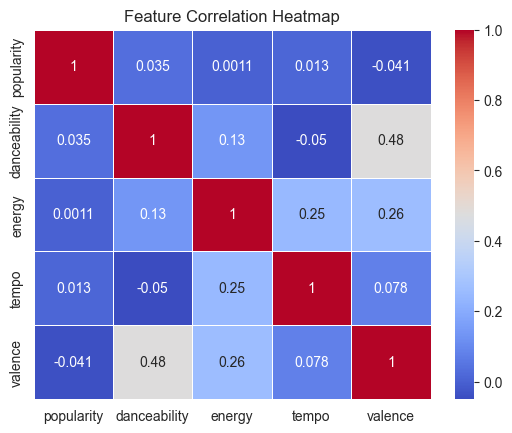

In [28]:
corr = df[["popularity", "danceability", "energy", "tempo", "valence"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

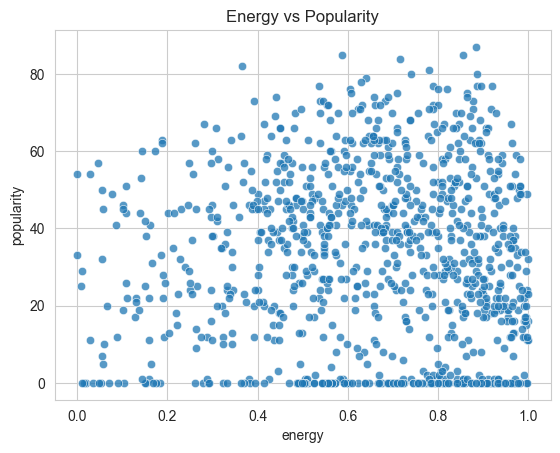

In [45]:
sample_df = df.sample(n=1000, random_state=42)

sns.scatterplot(x="energy", y="popularity", data=sample_df, alpha = 0.75)
plt.title("Energy vs Popularity")
plt.show()

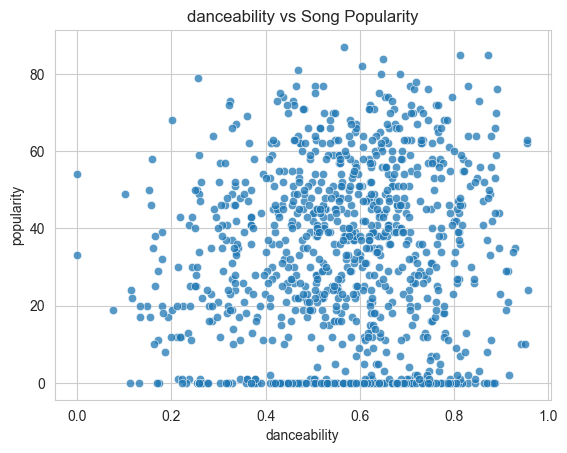

In [46]:
sample_df = df.sample(n=1000, random_state=42)

sns.scatterplot(x="danceability", y="popularity", data=sample_df, alpha=0.75)
plt.title("danceability vs Song Popularity")
plt.show()

In [47]:
dance_hits = df[(df["danceability"] > 0.7) & (df["popularity"] > 70)]

top_dance_hits = dance_hits.sort_values(by="popularity", ascending=False).head(10)

print(top_dance_hits)

       Unnamed: 0                track_id                     artists  \
20001       20001  3nqQXoyQOWXiESFLlDF1hG        Sam Smith;Kim Petras   
81051       81051  3nqQXoyQOWXiESFLlDF1hG        Sam Smith;Kim Petras   
67356       67356  5ww2BF9slyYgNOk37BlC4u               Manuel Turizo   
68303       68303  5ww2BF9slyYgNOk37BlC4u               Manuel Turizo   
89411       89411  5ww2BF9slyYgNOk37BlC4u               Manuel Turizo   
88410       88410  5ww2BF9slyYgNOk37BlC4u               Manuel Turizo   
68305       68305  6Sq7ltF9Qa7SNFBsV5Cogx  Bad Bunny;Chencho Corleone   
67358       67358  6Sq7ltF9Qa7SNFBsV5Cogx  Bad Bunny;Chencho Corleone   
88405       88405  6Sq7ltF9Qa7SNFBsV5Cogx  Bad Bunny;Chencho Corleone   
89407       89407  6Sq7ltF9Qa7SNFBsV5Cogx  Bad Bunny;Chencho Corleone   

                      album_name                 track_name  popularity  \
20001  Unholy (feat. Kim Petras)  Unholy (feat. Kim Petras)         100   
81051  Unholy (feat. Kim Petras)  Unholy (feat